# Volume experiment — new three-polytope format

For each quantization bit-width $b$, we have three nested polytopes per sample:
- $A_{\text{base}}$: model activation + model classification (model-only)
- $A_{\text{correct}}^b$: $A_{\text{base}}$ + qmodel activation
- $A_{\text{both}}^b$: $A_{\text{correct}}^b$ + qmodel classification

Containment: $A_{\text{base}} \supseteq A_{\text{correct}}^b \supseteq A_{\text{both}}^b$

This notebook plots two **generalized accuracy** curves (values in $[0, 1]$, closer to 1 = better quantization):
1. **Curve 1**: $\dfrac{\sum_i d\!\left(\Xi^b_{\boldsymbol{x}_i}\right)}{\sum_i d\!\left(\Xi^b_{S(\boldsymbol{x}_i)}\right)}$ — fraction of the base region preserved when requiring both models to agree (measures total quantization impact)
2. **Curve 2**: $\dfrac{\sum_i d\!\left(\Xi^b_{\boldsymbol{x}_i}\right)}{\sum_i d\!\left(\Xi^b_{S(\boldsymbol{x}_i) \wedge \tilde{S}(\boldsymbol{x}_i)}\right)}$ — fraction of the activation-constrained region preserved when adding qmodel classification constraints (measures classification alignment)
3. **Histogram**: number of zero `widths_both[b]` entries per bit-width (empty polytopes = qmodel misclassifies $x_0$)

## Setup

In [145]:
%load_ext autoreload
%autoreload 2

import json
import math
import os
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path(os.getcwd()).parent
sys.path.insert(0, str(ROOT))
print("Project root:", ROOT)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Project root: /Users/jeremiecabessa/Desktop/ROOT/Articles/Conference_Papers/2025_With_Jiri/code/ErrorVolumePolytopes


## Configuration

In [146]:
# ------------------------------------------------------------------ #
# Global config — change MODEL_TYPE to switch between MLP and CNN    #
# ------------------------------------------------------------------ #

MODEL_TYPE = "cnn"   # "mlp" or "cnn"
SAVE_PDF   = True    # save plots as PDF in the results directory

RESULTS_ROOT = ROOT / "results"
RESULTS_DIR = ROOT / "results" / f"volumes_{MODEL_TYPE}"
print(f"Model type  : {MODEL_TYPE}")
print(f"Results dir : {RESULTS_DIR}")
print(f"Save PDF    : {SAVE_PDF}")

Model type  : cnn
Results dir : /Users/jeremiecabessa/Desktop/ROOT/Articles/Conference_Papers/2025_With_Jiri/code/ErrorVolumePolytopes/results/volumes_cnn
Save PDF    : True


## Load results

In [147]:
def load_records(results_dir):
    recs = []
    for f in sorted(Path(results_dir).glob("volumes_sample*.json")):
        with open(f) as fh:
            recs.append(json.load(fh))
    return recs

records = load_records(RESULTS_DIR)
print(f"Found {len(records)} result files.")

bits_grid = sorted(int(b) for b in records[0]["widths_both"].keys())
print("Bits grid:", bits_grid)

Found 2000 result files.
Bits grid: [4, 6, 8, 10, 12, 16]


## Compute sums and track zero / NaN entries

- `width_base` and `widths_correct` should never be 0 or NaN (A_base and A_correct always contain $x_0$).
- `widths_both[b]` can be 0 when the qmodel misclassifies $x_0$ (empty polytope).

In [148]:
def is_bad(v):
    """True if value is 0, NaN, or None."""
    return v is None or math.isnan(v) or v == 0.0

# Accumulators
sum_base    = 0.0
sum_correct = {b: 0.0 for b in bits_grid}
sum_both    = {b: 0.0 for b in bits_grid}

# Track zero/NaN entries in widths_both: {b: list of sample_idx}
zero_both   = {b: [] for b in bits_grid}

for r in records:
    idx = r["sample_idx"]

    # width_base (single value per sample)
    wb = r["width_base"]
    sum_base += 0.0 if is_bad(wb) else wb

    for b in bits_grid:
        # widths_correct
        wc = r["widths_correct"][str(b)]
        sum_correct[b] += 0.0 if is_bad(wc) else wc

        # widths_both
        wbo = r["widths_both"][str(b)]
        if is_bad(wbo):
            zero_both[b].append(idx)
            sum_both[b] += 0.0
        else:
            sum_both[b] += wbo

# Summary dict
summary = {
    "n_samples":    len(records),
    "sum_base":     sum_base,
    "sum_correct":  sum_correct,
    "sum_both":     sum_both,
    "zero_both":    zero_both,
}

print(f"Samples       : {summary['n_samples']}")
print(f"sum_base      : {sum_base:.4f}")
print()
print(f"{'bits':>6}  {'sum_correct':>14}  {'sum_both':>12}  {'n_zeros':>8}")
for b in bits_grid:
    nz = len(zero_both[b])
    print(f"  {b:4d}  {sum_correct[b]:14.4f}  {sum_both[b]:12.4f}  {nz:8d}")

Samples       : 2000
sum_base      : 3003.8460

  bits     sum_correct      sum_both   n_zeros
     4       1491.8533     1487.3851         9
     6       2250.8870     2250.8280         0
     8       2715.3910     2715.3784         0
    10       2901.2164     2901.2150         0
    12       2982.0854     2982.0848         0
    16       3002.5754     3002.5753         0


## Plots

Saved to /Users/jeremiecabessa/Desktop/ROOT/Articles/Conference_Papers/2025_With_Jiri/code/ErrorVolumePolytopes/results/plot_gen_acc_both_over_base_cnn.pdf


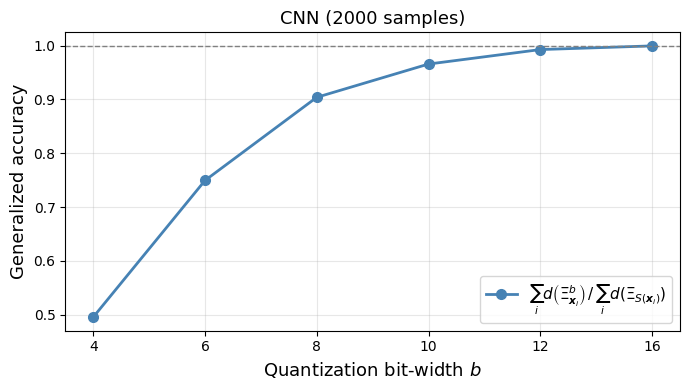

Saved to /Users/jeremiecabessa/Desktop/ROOT/Articles/Conference_Papers/2025_With_Jiri/code/ErrorVolumePolytopes/results/plot_gen_acc_both_over_correct_cnn.pdf


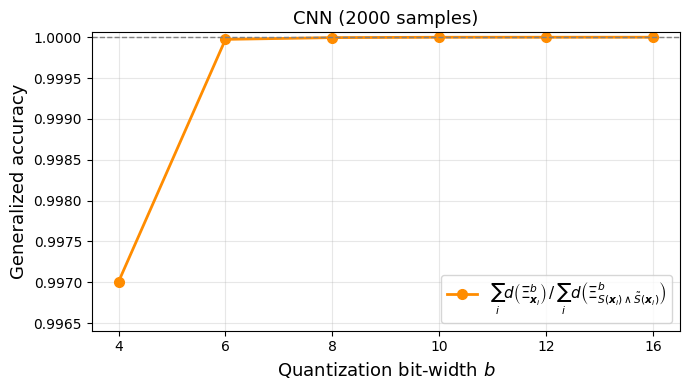

Saved to /Users/jeremiecabessa/Desktop/ROOT/Articles/Conference_Papers/2025_With_Jiri/code/ErrorVolumePolytopes/results/plot_empty_both_polytopes_cnn.pdf


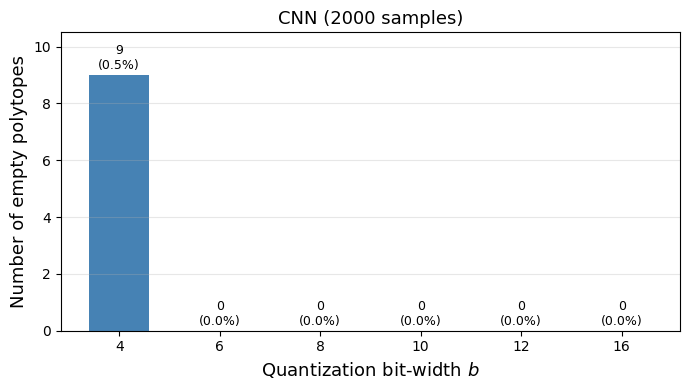

In [149]:
bits_arr = np.array(bits_grid)
x_ticks  = range(len(bits_grid))

gen_acc1 = np.array([sum_both[b] / sum_base          if sum_base > 0        else np.nan for b in bits_grid])
gen_acc2 = np.array([sum_both[b] / sum_correct[b]    if sum_correct[b] > 0  else np.nan for b in bits_grid])
n_zeros  = [len(zero_both[b]) for b in bits_grid]

# ------------------------------------------------------------------ #
# Figure 1: generalized accuracy — both / base                       #
# ------------------------------------------------------------------ #
fig, ax = plt.subplots(figsize=(7, 4))

formula = r"$\sum_{i} d \left( \Xi^b_{\boldsymbol{x}_i} \right) \,/\, \sum_{i} d \left( \Xi_{S(\boldsymbol{x}_i)} \right)$"

ax.plot(x_ticks, gen_acc1, marker="o", 
        linewidth=2, markersize=7, 
        label=formula, color="steelblue")
ax.axhline(1.0, color="gray", linestyle="--", linewidth=1)

ax.set_xlabel("Quantization bit-width $b$", fontsize=13)
ax.set_ylabel("Generalized accuracy", fontsize=13)
ax.set_title(
    f"{MODEL_TYPE.upper()} ({len(records)} samples)",
    fontsize=13
)
ax.set_xticks(x_ticks)
ax.set_xticklabels(bits_arr)
ax.legend(loc="lower right", fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
if SAVE_PDF:
    path = RESULTS_ROOT / f"plot_gen_acc_both_over_base_{MODEL_TYPE}.pdf"
    plt.savefig(path, bbox_inches="tight")
    print(f"Saved to {path}")
plt.show()

# ------------------------------------------------------------------ #
# Figure 2: generalized accuracy — both / correct  (zoomed in)      #
# ------------------------------------------------------------------ #
fig, ax = plt.subplots(figsize=(7, 4))

formula = r"$\sum_{i} d \left( \Xi^b_{\boldsymbol{x}_i} \right) \,/\, \sum_{i} d \left( \Xi^b_{S(\boldsymbol{x}_i) \wedge \tilde{S}(\boldsymbol{x}_i)} \right)$"

ax.plot(x_ticks, gen_acc2, marker="o", 
        linewidth=2, markersize=7, 
        label=formula, color="darkorange")
ax.axhline(1.0, color="gray", linestyle="--", linewidth=1)

# Zoom: bottom slightly below the minimum value, top fixed at 1
valid = gen_acc2[~np.isnan(gen_acc2)]
margin = max((1.0 - valid.min()) * 0.2, 1e-6)
ax.set_ylim(valid.min() - margin, 1.0 + margin * 0.1)

ax.set_xlabel("Quantization bit-width $b$", fontsize=13)
ax.set_ylabel("Generalized accuracy", fontsize=13)
ax.set_title(
    f"{MODEL_TYPE.upper()} ({len(records)} samples)",
    fontsize=13
)
ax.set_xticks(x_ticks)
ax.set_xticklabels(bits_arr)
ax.legend(loc="lower right", fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
if SAVE_PDF:
    path = RESULTS_ROOT / f"plot_gen_acc_both_over_correct_{MODEL_TYPE}.pdf"
    plt.savefig(path, bbox_inches="tight")
    print(f"Saved to {path}")
plt.show()

# ------------------------------------------------------------------ #
# Figure 3: zero / NaN histogram                                     #
# ------------------------------------------------------------------ #
fig, ax = plt.subplots(figsize=(7, 4))

ax.bar(x_ticks, n_zeros, color="steelblue", width=0.6)
ax.set_xlabel("Quantization bit-width $b$", fontsize=13)
ax.set_ylabel("Number of empty polytopes", fontsize=13)
ax.set_title(
    f"{MODEL_TYPE.upper()} ({len(records)} samples)",
    fontsize=13
)
ax.set_xticks(x_ticks)
ax.set_xticklabels(bits_arr)
ax.grid(True, axis="y", alpha=0.3)
ax.set_ylim(0, max(n_zeros) + 1.5)

for i, (b, n) in enumerate(zip(bits_grid, n_zeros)):
    pct = 100 * n / len(records)
    ax.text(i, n + 0.1, f"{n}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
if SAVE_PDF:
    path = RESULTS_ROOT / f"plot_empty_both_polytopes_{MODEL_TYPE}.pdf"
    plt.savefig(path, bbox_inches="tight")
    print(f"Saved to {path}")
plt.show()

## Mean and std of widths per bit-width

width_base    : mean=1.5019  std=0.3888

  bits    mean_correct   std_correct     mean_both    std_both
     4          0.7459        0.2755       -0.2563      0.2755
     6          1.1254        0.3279        0.1254      0.3279
     8          1.3577        0.3751        0.3577      0.3751
    10          1.4506        0.3865        0.4506      0.3865
    12          1.4910        0.3879        0.4910      0.3879
    16          1.5013        0.3887        0.5013      0.3887
Saved to /Users/jeremiecabessa/Desktop/ROOT/Articles/Conference_Papers/2025_With_Jiri/code/ErrorVolumePolytopes/results/plot_mean_std_widths_cnn.pdf


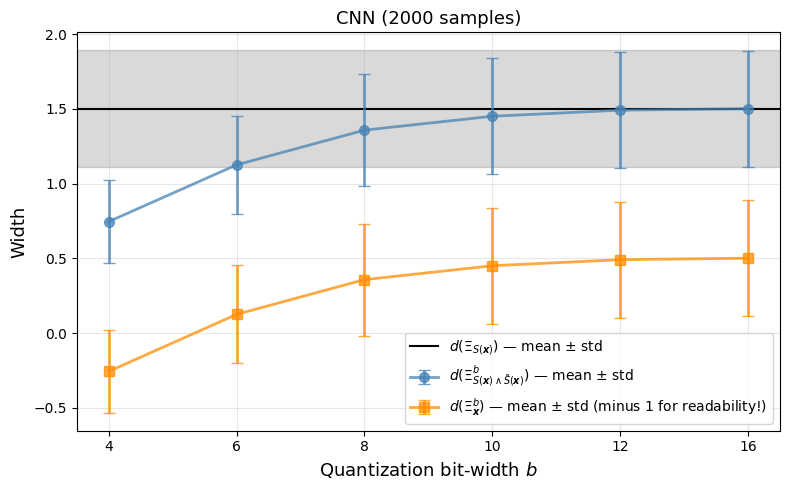

In [150]:
import numpy as np

# Collect per-sample arrays
arr_base    = np.array([r["width_base"] for r in records])
arr_correct = {b: np.array([r["widths_correct"][str(b)] for r in records]) for b in bits_grid}
arr_both    = {b: np.array([r["widths_both"][str(b)]    for r in records]) for b in bits_grid}

# Means and stds
mean_base = arr_base.mean();  std_base = arr_base.std()

mean_correct = np.array([arr_correct[b].mean() for b in bits_grid])
std_correct  = np.array([arr_correct[b].std()  for b in bits_grid])

mean_both    = np.array([arr_both[b].mean() for b in bits_grid]) - 1 # minus 1 for readability)
std_both     = np.array([arr_both[b].std()  for b in bits_grid])

print(f"width_base    : mean={mean_base:.4f}  std={std_base:.4f}")
print()
print(f"{'bits':>6}  {'mean_correct':>14}  {'std_correct':>12}  {'mean_both':>12}  {'std_both':>10}")
for i, b in enumerate(bits_grid):
    print(f"  {b:4d}  {mean_correct[i]:14.4f}  {std_correct[i]:12.4f}  {mean_both[i]:12.4f}  {std_both[i]:10.4f}")

# ------------------------------------------------------------------ #
# Plot: mean ± std of width_base, widths_correct, widths_both        #
# ------------------------------------------------------------------ #
fig, ax = plt.subplots(figsize=(8, 5))

x = np.arange(len(bits_grid))

# width_base: constant across b — draw as horizontal band
ax.axhline(mean_base, color="black", linewidth=1.5, linestyle="-",  label=r"$d(\Xi_{S(\boldsymbol{x})})$ — mean ± std")
ax.axhspan(mean_base - std_base, mean_base + std_base, alpha=0.15, color="black")

# widths_correct
ax.errorbar(x, mean_correct, yerr=std_correct, marker="o", linewidth=2, markersize=7,
            capsize=4, color="steelblue", alpha=0.75,
            label=r"$d(\Xi^b_{S(\boldsymbol{x}) \wedge \tilde{S}(\boldsymbol{x})})$ — mean ± std")

# widths_both
ax.errorbar(x, mean_both, yerr=std_both, marker="s", linewidth=2, markersize=7,
            capsize=4, color="darkorange", alpha=0.75,
            label=r"$d(\Xi^b_{\boldsymbol{x}})$ — mean ± std (minus 1 for readability!)")

ax.set_xlabel("Quantization bit-width $b$", fontsize=13)
ax.set_ylabel("Width", fontsize=13)
ax.set_title(f"{MODEL_TYPE.upper()} ({len(records)} samples)", fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(bits_grid)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
if SAVE_PDF:
    path = RESULTS_ROOT / f"plot_mean_std_widths_{MODEL_TYPE}.pdf"
    plt.savefig(path, bbox_inches="tight")
    print(f"Saved to {path}")
plt.show()

## Inspect zero / NaN samples per bit-width

In [151]:
for b in bits_grid:
    idxs = zero_both[b]
    print(f"bits={b:2d}  n_zeros={len(idxs):4d}  sample_indices={idxs[:20]}{'...' if len(idxs) > 20 else ''}")

bits= 4  n_zeros=   9  sample_indices=[1001, 1442, 1465, 1466, 1502, 1803, 190, 622, 63]
bits= 6  n_zeros=   0  sample_indices=[]
bits= 8  n_zeros=   0  sample_indices=[]
bits=10  n_zeros=   0  sample_indices=[]
bits=12  n_zeros=   0  sample_indices=[]
bits=16  n_zeros=   0  sample_indices=[]
